In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib as mpl
from matplotlib.ticker import NullLocator, AutoMinorLocator
import matplotlib.ticker as mticker
from matplotlib import rcParams
from metpy.plots import ctables
import metpy.calc


#### Plot settings: 
rcParams['font.family'] = 'serif'
rcParams['mathtext.fontset'] = 'cm'
rcParams['mathtext.rm'] = 'serif'
mpl.rcParams["figure.dpi"] = 350
plt.rcParams['hatch.linewidth'] = 0.35


### Define any needed functions, constants, or other settings: 

In [2]:
def makeHistData(data, point_limit, binNum):
    ### flatten the data
    data_flat = data.values.flatten()

    # calculate the histogram
    hist_data, bin_edges_data = np.histogram(data_flat, bins=binNum, density=False)

    # limit the histogram to only include points with at least n points = pointLimit as defined by the user
    hist_data_lim = xr.DataArray(hist_data).where(hist_data > (point_limit))

    # make a list from which the hist_data_lim and bin_edges_data can be retreived
    hist_data_list = []
    hist_data_list.append(hist_data_lim)
    hist_data_list.append(bin_edges_data[:-1])

    return hist_data_list


#### Load the data: 

In [3]:
variables = ['winterp', 'prate', 'rain', 'cph']
path = '/glade/u/home/mfranke/work/CM1/casper/derecho_comp/cm1r21.1/cm1.runs/Simulations/'
version = 'v455'

### Open the files: 
ds_ctrl = xr.open_dataset(path + f'cm1out_ctrl_{version}_1600.nc', decode_timedelta = True).isel(time = slice(0,81))[variables]
ds_lens = xr.open_dataset(path + f'cm1out_lens_{version}_1600.nc', decode_timedelta = True).isel(time = slice(0,81))[variables]
ds_crh = xr.open_dataset(path + f'cm1out_lens_{version}_1600_constantRH_20hrs.nc', decode_timedelta = True)[variables]

datasets = {
    'CTRL' : ds_ctrl,
    'LENS2' : ds_lens, 
    'CRH' : ds_crh}

### Set the dimensions: 
time_minutes = ds_ctrl.time/ np.timedelta64(1, 'm')
time_hours = ds_ctrl.time/ np.timedelta64(1, 'h')


In [4]:
### Define variable for histogram:
var = 'rain'
var_name = 'Accumulated Rainfall'
var_units = 'mm'

### Set the bins for the histogram:
points = 5
all_vals = np.concatenate([dsr[var].values.ravel() for dsr in datasets.values()])
shared_min = np.nanmin(all_vals)    ### This can also be a percentile:  np.percentile(all_vals, 99) for 99th percentile  
shared_max = np.nanmax(all_vals) 
bins = np.linspace(shared_min, shared_max, 60)

### Compute the histograms: 
histograms = {label: [] for label in datasets}
for label, dsr in datasets.items():
    print(f'Processing {label}...')
    histograms[label] = makeHistData(dsr[var], points, bins)
    print('Done.')

Processing CTRL...
Done.
Processing LENS2...
Done.
Processing CRH...
Done.


In [5]:
### Any other data pre-processing before plotting: 
## Ex: change prate to proper units by multipying by 3600; cm to mm multiply by 10
for label in histograms:
    histograms[label][1] = histograms[label][1] * 10


### Plotting: 

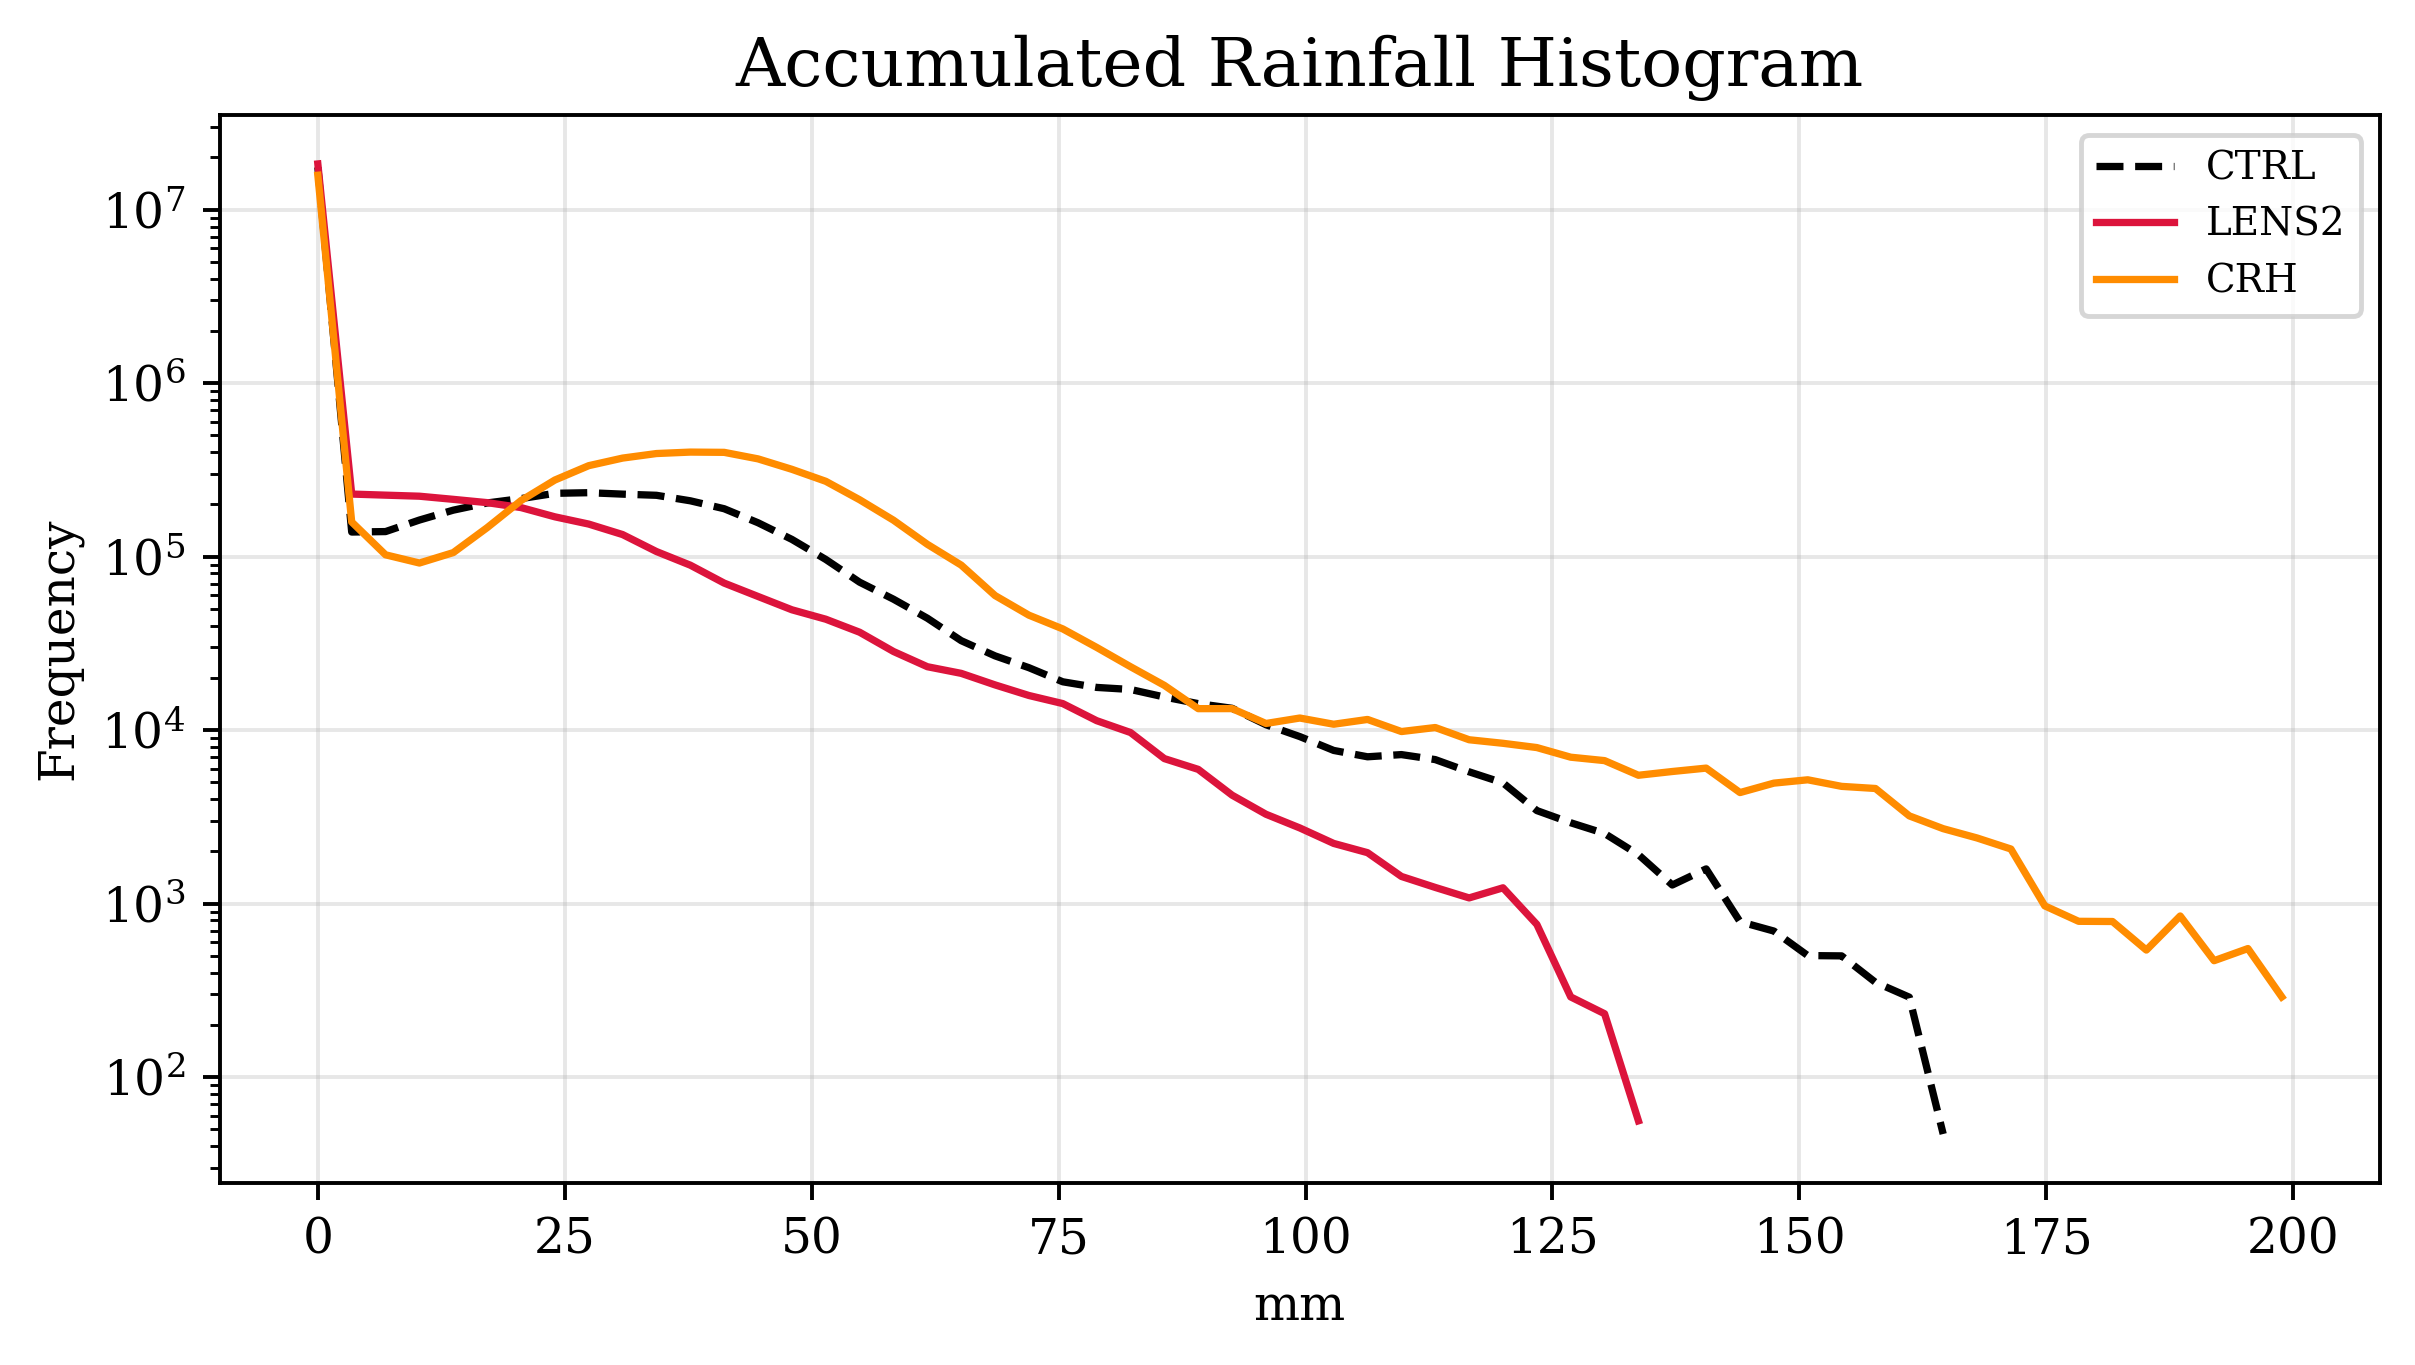

In [6]:
### Plot settings: 
colors = {'CTRL': 'black', 'LENS2': 'crimson', 'CRH': 'darkorange'}
styles = {'CTRL': '--', 'LENS2': '-', 'CRH': '-'}

fs_title = 14
fs_axislabel = 10
fs_legend = 8
fs_subtitle = 10

##=============================================================
fig, axes = plt.subplots(1, 1, figsize=(7, 4), sharex=True)
for label in datasets:
    axes.plot(histograms[label][1], histograms[label][0], styles[label], color=colors[label], label=label)
axes.set_title(f'{var_name} Histogram', fontsize = fs_title)
axes.set_ylabel('Frequency', fontsize = fs_axislabel)
axes.grid(alpha=0.3)
axes.legend(fontsize = fs_legend)
axes.set_xlabel(f'{var_units}', fontsize = fs_axislabel)
plt.yscale('log')

fig.tight_layout()

### Save figure: 
# plt.savefig(f'./Figures/{var_name}_histogram_3runs.jpg', bbox_inches = 'tight')
